<a href="https://colab.research.google.com/github/AllaYermilko/Analysis_Cafe_Sales/blob/main/EDA_Cafe_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis Cafe Sales**

*Cafe Sales - Dirty Data for Cleaning Training*

**Overview**

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

**File Information:**

- File Name: dirty_cafe_sales.csv
- Number of Rows: 10,000
- Number of Columns: 8

- `Transaction ID` -	A unique identifier for each transaction. Always present and unique.	TXN_1234567
- `Item` -	The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").	Coffee, Sandwich
- `Quantity` -	The quantity of the item purchased. May contain missing or invalid values.	1, 3, UNKNOWN
- `Price Per Unit` -	The price of a single unit of the item. May contain missing or invalid values.	2.00, 4.00
- `Total Spent` -	The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.	8.00, 12.00
- `Payment Method` -	The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN").	Cash, Credit Card
- `Location` -	The location where the transaction occurred. May contain missing or invalid values.	In-store, Takeaway
- `Transaction Date` -	The date of the transaction. May contain missing or incorrect values.	2023-01-01

In [1]:
!pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
# FILE_IN = "cafe_sales.csv"

FILE_IN = 'https://raw.githubusercontent.com/AllaYermilko/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'
# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"






# Loading the dataset

In [4]:
df_origin = pd.read_csv(FILE_IN)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df = df_origin.copy()

# **Primary diagnosis / Первинна діагностика**

In [6]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [8]:
print('Data type (raw):\n')
df.dtypes

Data type (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:

- Numeric columns (Quantity, Price Per Unit, Total Spent)  
- Date columns (Transaction Date)

In [9]:
print('Missing values:\n')
missing = df.isnull().sum()
missing_pct = (missing / len(df) *100).round()
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.0
Quantity,138,1.0
Price Per Unit,179,2.0
Total Spent,173,2.0
Payment Method,2579,26.0
Location,3265,33.0
Transaction Date,159,2.0


In [10]:
print('Unique values:\n')

print('---Item---\n')
# print(df['Item'].value_counts(dropna=False))
display(df['Item'].value_counts(dropna=False))

print('\n---Payment Method---\n')
display(df['Payment Method'].value_counts(dropna=False))

print('\n---Location---\n')
display(df['Location'].value_counts(dropna=False))

Unique values:

---Item---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



---Payment Method---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



---Location---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [11]:
print('Find lines with "ERROR" or "UNKNOWN"\n')
# df.isin(["ERROR" or "UNKNOWN"]).any()
display(df.isin(["ERROR" or "UNKNOWN"]).sum())

mask_error = df.isin(["ERROR","UNKNOWN"]).any(axis=1)
print(f'\nFind lines with "ERROR" or "UNKNOWN": {mask_error.sum()}')

Find lines with "ERROR" or "UNKNOWN"



,0
Transaction ID,0
Item,292
Quantity,170
Price Per Unit,190
Total Spent,164
Payment Method,306
Location,358
Transaction Date,142



Find lines with "ERROR" or "UNKNOWN": 2845


# Data cleaning

- `df_origin` - origin dataset  
- `df` - copy origin dataset

In [12]:
print("Rename columns:\n")

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [13]:
"_".join("     Transaction   Date   ".lower().split())

'transaction_date'

In [14]:
"   Transaction   Date   ".strip().lower().replace(" ", "_")

'transaction___date'

In [15]:
"   Transaction Date   ".strip().lower().replace(" ", "_")

'transaction_date'

In [16]:
df.columns.str.lower().str.split()

Index([  ['transaction_id'],             ['item'],         ['quantity'],
         ['price_per_unit'],      ['total_spent'],   ['payment_method'],
               ['location'], ['transaction_date']],
      dtype='object')

In [17]:
# 'ERROR'/'UNKNOWN' -> NaN
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [18]:
for col in ['quantity', 'price_per_unit', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [19]:
print('Convering columns:\n')
df.dtypes

Convering columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [20]:
# Extracting time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int8')

# df['month_name'] = df['transaction_date'].dt.month.name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')  # B - повна версія назви, b - скорочена

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')

display(df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].head()

,0
transaction_date,datetime64[ns]
year,Int64
month,Int8
month_name,object
weekday,object
week,Int8


,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [21]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string(quantity * price)")


Restoring total_spent: 462 string(quantity * price)


In [22]:
# dict of median prices
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()
df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)
print(f"Restoring total_spent: {mask_price.sum()} string(median per item)")

# mask_price.sum()
# df.loc[mask_price, 'item'].map(price_map)
# df[58:59]

Restoring total_spent: 479 string(median per item)


In [23]:
type(df[mask_price]) # DataFrame
type(df[mask_price]['item']) # Series
type(df[mask_price][['item', 'price_per_unit']]) # DataFrame

type(df.loc[mask_price]['item']) # Series
type(df.loc[mask_price][['item', 'price_per_unit']]) # DataFrame

pandas.core.frame.DataFrame

In [24]:
# Restoring total_spent (new_price - median item)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string(new_price - median item)")

Restoring total_spent: 17 string(new_price - median item)


In [25]:
# fillna item -> mode
mode_item = df['item'].mode()[0]

# df['item'].fillna(mode_item, inplace=True) # old version
df.fillna({'item': mode_item}, inplace=True)

In [26]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'

    },
    inplace=True
)

In [27]:
# 'Delete transaction_date and quantity where NaT or NaN
before = len(df)
df.dropna(subset=['transaction_date', 'quantity'], inplace=True)


after = len(df)
print(f"Deleted {before - after} rows")

Deleted 914 rows


In [28]:
# Delete duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [29]:
# Перевірка на наявність вд'ємних значень
(df.quantity <= 0).sum()
(df.price_per_unit <= 0).sum()
(df.total_spent <= 0).sum()

np.int64(0)

In [30]:
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [31]:
(df['quantity'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [32]:
df[['item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week']].duplicated().sum()

np.int64(192)

In [33]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9086 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9086 non-null   object        
 1   item              9086 non-null   object        
 2   quantity          9086 non-null   float64       
 3   price_per_unit    9038 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9086 non-null   object        
 6   location          9086 non-null   object        
 7   transaction_date  9086 non-null   datetime64[ns]
 8   year              9086 non-null   Int64         
 9   month             9086 non-null   Int8          
 10  month_name        9086 non-null   object        
 11  weekday           9086 non-null   object        
 12  week              9086 non-null   Int8          
dtypes: Int64(1), Int8(2), datetime64[ns](1), float64(3), object(6)
memory usage: 896.2+

,0
transaction_id,0
item,0
quantity,0
price_per_unit,48
total_spent,3
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [34]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)
df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [35]:
df.dropna(subset=['total_spent'], inplace=True)
print(f"Delete rows with NaN")

Delete rows with NaN


In [36]:
df.isna().sum().sum()

np.int64(0)

In [37]:
# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit !=df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 0


In [38]:
# Text fields are standertized (Text Case)
for col in ['item', 'payment_method', 'location']:
  df[col] = df[col].str.strip().str.title()
print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


# **Cleaning results**

In [39]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results:\n")
print("=" * 20, "\n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("\n---Residual gaps:---")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\n---Data types after cleanup:---")
# print(df.dtypes)
display(df.dtypes)

print("\n---Statistics ---")
print(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))

Cleaning results:


Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

---Residual gaps:---
No gaps

---Data types after cleanup:---


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,Int64
month,Int8



---Statistics ---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


# **Feature Engineering**

In [40]:
# Season

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# df[['month', 'season']].head()

In [41]:
# Is weekend

df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [42]:
# Check amount category

df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)


In [43]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


In [44]:
df[df['total_spent'] > 20]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,Tuesday,45,Autumn,False,Premium
51,TXN_6342161,Salad,5.0,5.0,25.0,Unknown,Takeaway,2023-01-08,2023,1,January,Sunday,1,Winter,True,Premium
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Unknown,2023-03-15,2023,3,March,Wednesday,11,Spring,False,Premium
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-Store,2023-06-10,2023,6,June,Saturday,23,Summer,True,Premium
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30,2023,10,October,Monday,44,Autumn,False,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-01-04,2023,1,January,Wednesday,1,Winter,False,Premium
9805,TXN_9506076,Salad,5.0,5.0,25.0,Unknown,Unknown,2023-01-17,2023,1,January,Tuesday,3,Winter,False,Premium
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-10-19,2023,10,October,Thursday,42,Autumn,False,Premium
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Unknown,2023-06-22,2023,6,June,Thursday,25,Summer,False,Premium


In [45]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20,Spring,False,High
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29,Summer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23,Summer,True,Low


## Fast EDA (verification graphs)

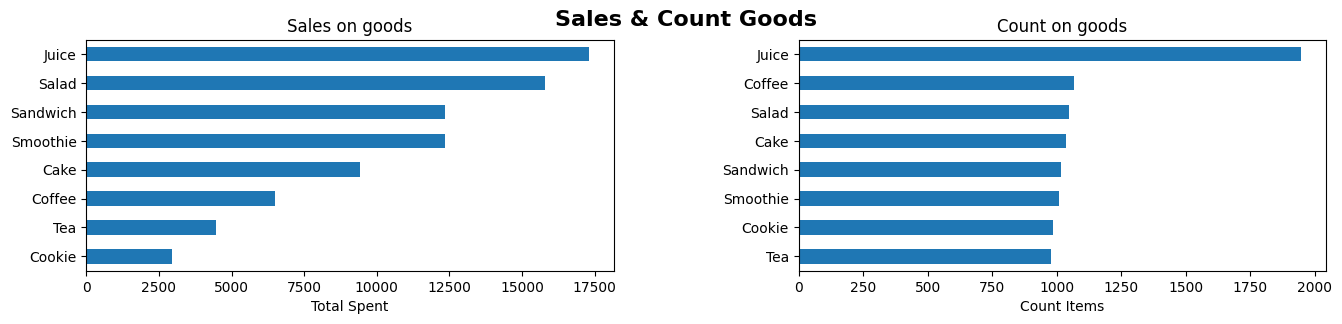

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
fig.suptitle("Sales & Count Goods", fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item

ax = axes[0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Sales on goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")

# count per item
ax = axes[1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Count on goods")
ax.set_xlabel("Count Items")
ax.set_ylabel("")

plt.show()

In [47]:
set(list(df['month_name'].values))

{'April',
 'August',
 'December',
 'February',
 'January',
 'July',
 'June',
 'March',
 'May',
 'November',
 'October',
 'September'}

In [48]:
import calendar
print([calendar.month_name[i] for i in range(1, 13)])

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


NameError: name 'std_pct' is not defined

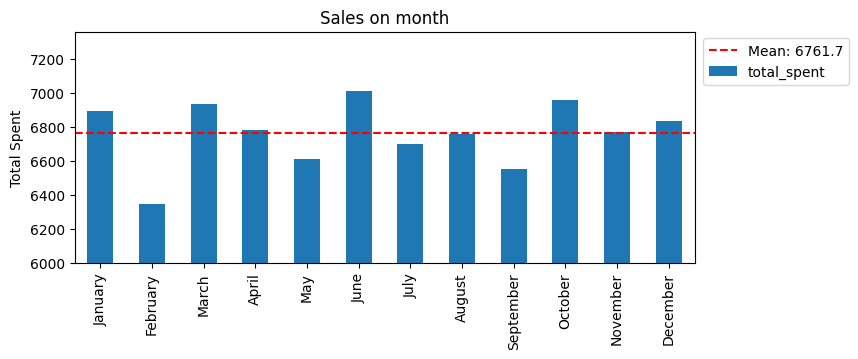

In [55]:
# Sales on month
fig = plt.figure(figsize=(8,3))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December'
]

# print(df.groupby('month_name')['total_spent'].sum())
rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]
    )

rev_month.plot(kind='bar')

mean_value = rev_month.mean()
# std_value = rev_month.std()
# std_pct = (std_value / mean_value) * 100

# print(mean_value)
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_value:.1f}")

plt.ylim(bottom=6000)
plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
plt.legend(bbox_to_anchor=(1.26, 1), loc='upper right')

plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
         )
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')
plt.show()

Додати графіки за власни поглядом

In [ ]:
# Save figures
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')

# Saving a clean CSV for Tableau

In [ ]:
# df['transaction_date'] = df_origin['Transaction Date'].copy()
# df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [56]:
q = 0
try:
  a = 1 / 0
  q = 1
except Exception as e:
  print("Error:", e)
else:
  print("Спроба ділення")
finally:
  if q:
    print("Виконався try")
  else:
    print("Виконався except")

Error: division by zero
Виконався except


In [57]:
# For Tableau bette date format: YYYY-MM-DD
try:
  df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')
except:
  print("transaction_date was changed - (%Y-%m-%d)\n")

# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

# print(f"Saved: {FILE_OUT}")
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

Rows: 9083 | Columns: 16
Columns: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']


# SUMMARY REPORT

In [64]:
print(f"Total revenue:          {df['total_spent'].sum():>14,.2f}")
print(f"Number of transactions: {len(df):>14,.2f}")
print(f"Average check:          {df['total_spent'].mean():>14,.2f}")
print(f"Median check:           {df['total_spent'].median():>14,.2f}")
print(f"Unique products:        {df['item'].nunique():>14,.2f}")
# print(f"Unique locations:       {df['location'].nunique():>14,.2f}")

all_location = df.loc[df['location'] != "Unknown", 'location']
print(f"Unique locations:       {all_location.nunique():>14,}")

top_item = df.groupby('item')['total_spent'].sum().idxmax()
print(f"Top profitable product: {top_item:>14}")

# top_pay = df['payment_method'].value_counts()
# top_pay.dop('Unknown', errors='ignore').idxmax()

all_pay_method = df.loc[df['payment_method'] != "Unknown", 'payment_method']
top_pay = all_pay_method.value_counts().idxmax()

print(f"Unique payment method:  {all_pay_method.nunique():>14,.2f}")
print(f"Top payment method:     {top_pay:>14}")

Total revenue:               81,140.00
Number of transactions:       9,083.00
Average check:                    8.93
Median check:                     8.00
Unique products:                  8.00
Unique locations:                    2
Top profitable product:          Juice
Unique payment method:            3.00
Top payment method:     Digital Wallet
